In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configure visual style
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'


# eda done on cleaned dataset
df = pd.read_csv('Cleaned_DataCo_Logistics.csv')
print(f'Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns\n')

eda_cols = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Sales per customer',
    'Dispatch_Lead_Days',
    'Delivery_SLA_Variance',
    'Late_delivery_risk',
]

print('--- EXPLORATORY DATA ANALYSIS: STATISTICAL SUMMARY ---')

stats_summary = df[eda_cols].describe()
print(stats_summary)

print('--- CORRELATION MATRIX ---')

corr_matrix = df[eda_cols].corr(method='pearson')
print(corr_matrix)


Dataset Loaded: 180519 rows, 59 columns

--- EXPLORATORY DATA ANALYSIS: STATISTICAL SUMMARY ---
       Days for shipping (real)  Days for shipment (scheduled)  \
count             180519.000000                  180519.000000   
mean                   3.497654                       2.931847   
std                    1.623722                       1.374449   
min                    0.000000                       0.000000   
25%                    2.000000                       2.000000   
50%                    3.000000                       4.000000   
75%                    5.000000                       4.000000   
max                    6.000000                       4.000000   

       Sales per customer  Dispatch_Lead_Days  Delivery_SLA_Variance  \
count       180519.000000       180519.000000          180519.000000   
mean           180.597083            3.498826               0.565807   
std            104.383766            1.617394               1.490966   
min              7.49

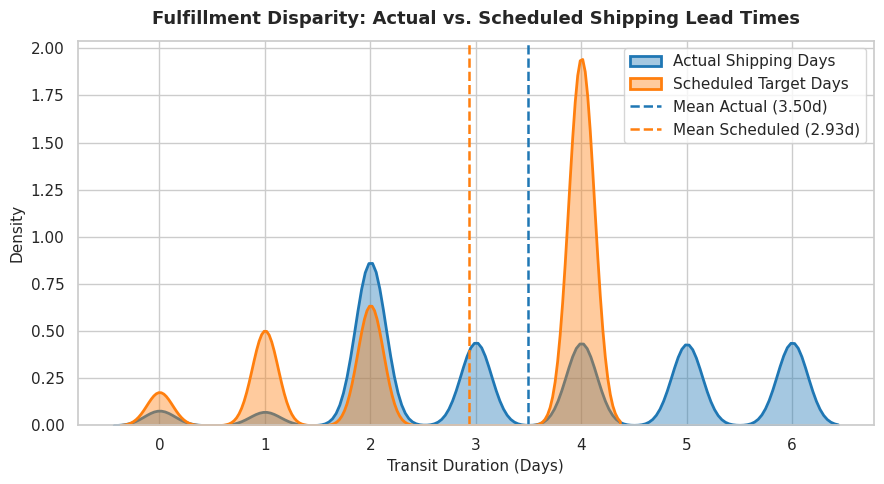

In [5]:
# 2. GENERATE AND DISPLAY 5 CHARTS FOR SCREENSHOTS

# CHART 1: Actual vs. Scheduled Lead Time Distribution (KDE Density)
plt.figure(figsize=(9, 5))
sns.kdeplot(
    data=df,
    x='Days for shipping (real)',
    fill=True,
    color='#1f77b4',
    label='Actual Shipping Days',
    alpha=0.4,
    linewidth=2,
)
sns.kdeplot(
    data=df,
    x='Days for shipment (scheduled)',
    fill=True,
    color='#ff7f0e',
    label='Scheduled Target Days',
    alpha=0.4,
    linewidth=2,
)

plt.axvline(
    df['Days for shipping (real)'].mean(),
    color='#1f77b4',
    linestyle='--',
    linewidth=1.8,
    label=f"Mean Actual ({df['Days for shipping (real)'].mean():.2f}d)",
)
plt.axvline(
    df['Days for shipment (scheduled)'].mean(),
    color='#ff7f0e',
    linestyle='--',
    linewidth=1.8,
    label=f"Mean Scheduled ({df['Days for shipment (scheduled)'].mean():.2f}d)",
)

plt.title(
    'Fulfillment Disparity: Actual vs. Scheduled Shipping Lead Times',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Transit Duration (Days)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1064/3929819417.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


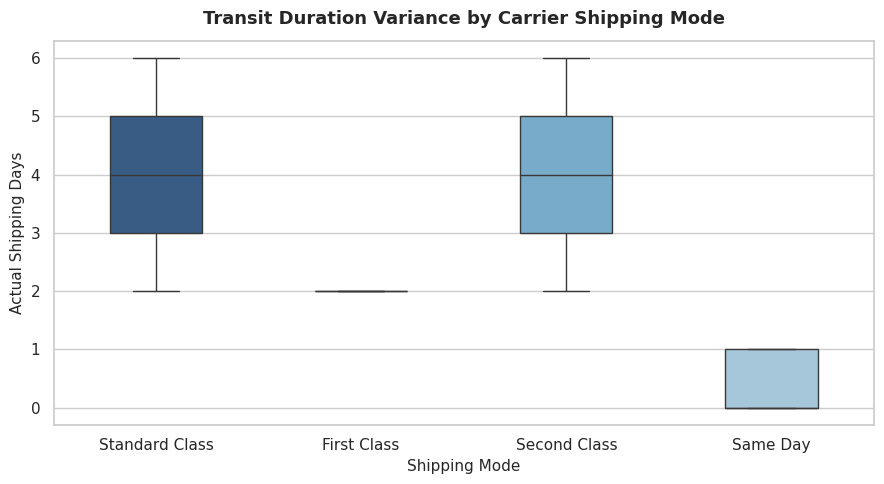

In [6]:
# CHART 2: Delivery Transit Variance Across Shipping Modes (Box Plot)
plt.figure(figsize=(9, 5))
palette = ['#2b5c8f', '#4682b4', '#6baed6', '#9ecae1']
sns.boxplot(
    data=df,
    x='Shipping Mode',
    y='Days for shipping (real)',
    palette=palette,
    width=0.45,
    fliersize=3,
)

plt.title(
    'Transit Duration Variance by Carrier Shipping Mode',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Shipping Mode', fontsize=11)
plt.ylabel('Actual Shipping Days', fontsize=11)
plt.tight_layout()
plt.show()


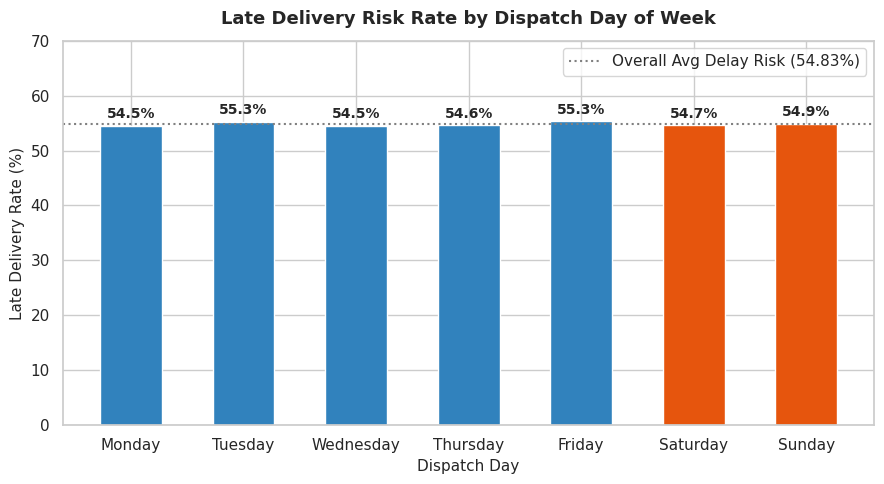

In [7]:
# CHART 3: Delay Risk Across Dispatch Days of the Week (Bar Chart)
day_mapping = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday',
}
df['Day_Name'] = df['Dispatch_Day_Of_Week'].map(day_mapping)
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]

weekday_delay = (
    df.groupby('Day_Name')['Late_delivery_risk']
    .mean()
    .reindex(day_order)
    .reset_index()
)
weekday_delay['Delay_Rate_Pct'] = weekday_delay['Late_delivery_risk'] * 100

plt.figure(figsize=(9, 5))
bar_colors = [
    '#3182bd' if day not in ['Saturday', 'Sunday'] else '#e6550d'
    for day in day_order
]
bars = plt.bar(
    weekday_delay['Day_Name'],
    weekday_delay['Delay_Rate_Pct'],
    color=bar_colors,
    width=0.55,
)
plt.axhline(
    54.83,
    color='gray',
    linestyle=':',
    linewidth=1.5,
    label='Overall Avg Delay Risk (54.83%)',
)

for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2.0,
      yval + 0.8,
      f'{yval:.1f}%',
      ha='center',
      va='bottom',
      fontsize=10,
      fontweight='bold',
  )

plt.title(
    'Late Delivery Risk Rate by Dispatch Day of Week',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Dispatch Day', fontsize=11)
plt.ylabel('Late Delivery Rate (%)', fontsize=11)
plt.ylim(0, 70)
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.tight_layout()
plt.show()


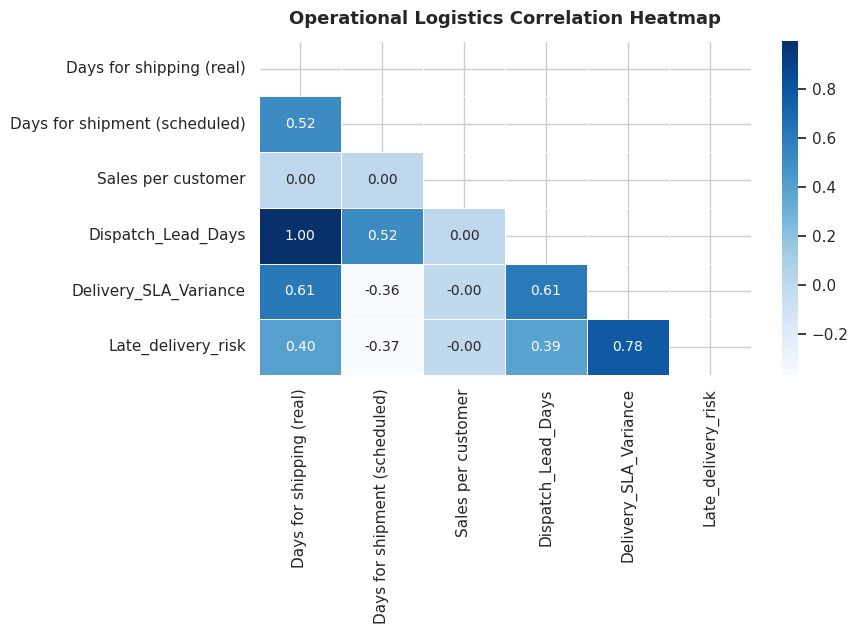

In [8]:
# CHART 4: Multivariate Correlation Heatmap
plt.figure(figsize=(9, 6.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    mask=mask,
    cbar=True,
    linewidths=0.5,
    annot_kws={'size': 10},
)

plt.title(
    'Operational Logistics Correlation Heatmap',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.tight_layout()
plt.show()


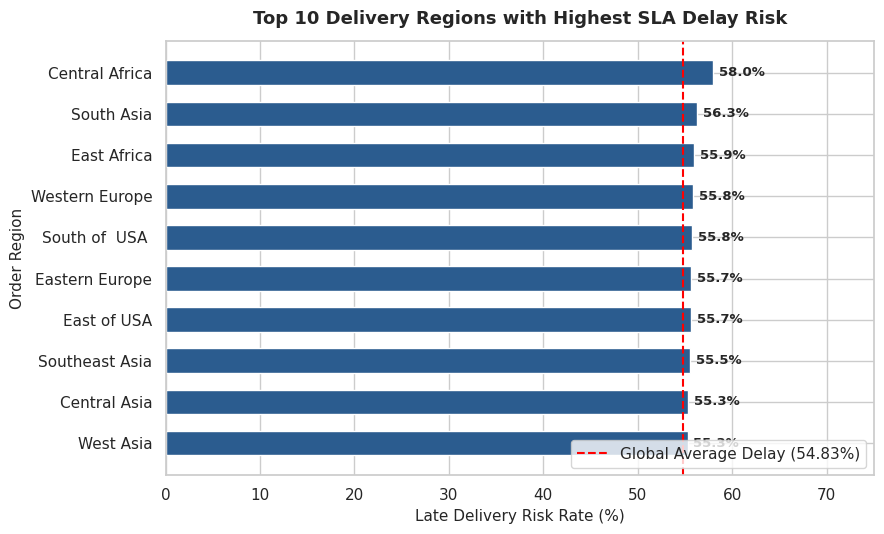

In [9]:
# CHART 5: Top 10 Delivery Regions by Delay Risk (Horizontal Bar Chart)
region_delay = (
    df.groupby('Order Region')['Late_delivery_risk']
    .agg(['mean', 'count'])
    .query('count > 500')
    .sort_values(by='mean', ascending=True)
    .tail(10)
    .reset_index()
)
region_delay['Late_Pct'] = region_delay['mean'] * 100

plt.figure(figsize=(9, 5.5))
bars = plt.barh(
    region_delay['Order Region'],
    region_delay['Late_Pct'],
    color='#2b5c8f',
    height=0.6,
)
plt.axvline(
    54.83,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Global Average Delay (54.83%)',
)

for bar in bars:
  xval = bar.get_width()
  plt.text(
      xval + 0.6,
      bar.get_y() + bar.get_height() / 2.0,
      f'{xval:.1f}%',
      ha='left',
      va='center',
      fontsize=9.5,
      fontweight='bold',
  )

plt.title(
    'Top 10 Delivery Regions with Highest SLA Delay Risk',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Late Delivery Risk Rate (%)', fontsize=11)
plt.ylabel('Order Region', fontsize=11)
plt.xlim(0, 75)
plt.legend(frameon=True, facecolor='white', loc='lower right')
plt.tight_layout()
plt.show()